# Сравнение регрессоров на California Housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna

warnings.filterwarnings("ignore")

In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame.sample(n=10000, random_state=42)

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.head(10).to_string())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.521
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85    -122.25        3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85    -122.25        3.422
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85    -122.25        2.697
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84    -122.25        2.992
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84    -122.25        2.414
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84    -122.26        2.267
9  3.6912      52.0  4.970588 

In [4]:
models = {
    "Linear": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(),
    "Huber": HuberRegressor(),
    "BayesianRidge": BayesianRidge(),
    "DecisionTree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(),
    "ExtraTrees": ExtraTreesRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": XGBRegressor(verbosity=0),
    "LightGBM": LGBMRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0),
}

In [5]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append((name, mae, mse, rmse, r2))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"]).sort_values(by="RMSE")
print("Сравнение моделей по метрикам:")
print(results_df.to_string(index=False))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 8
[LightGBM] [Info] Start training from score 2.057377
Сравнение моделей по метрикам:
           Model      MAE      MSE     RMSE        R²
        CatBoost 0.302364 0.206920 0.454884  0.851492
        LightGBM 0.319027 0.226351 0.475764  0.837546
         XGBoost 0.336319 0.252333 0.502328  0.818899
    RandomForest 0.349633 0.280964 0.530061  0.798350
GradientBoosting 0.372110 0.287876 0.536541  0.793390
      ExtraTrees 0.352260 0.288227 0.536868  0.793137
             KNN 0.435637 0.420135 0.648178  0.698466
           Huber 0.499342 0.507409 0.712327  0.635829
          Linear 0.540447 0.542707 0.736687  0.610496
           Ridge 0.540441

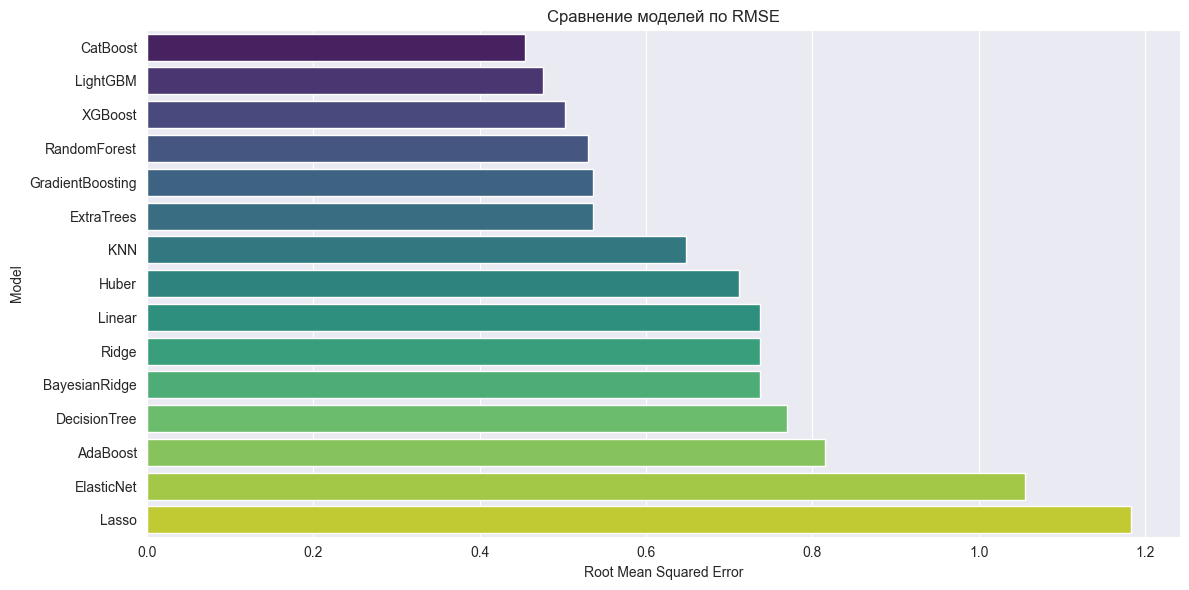

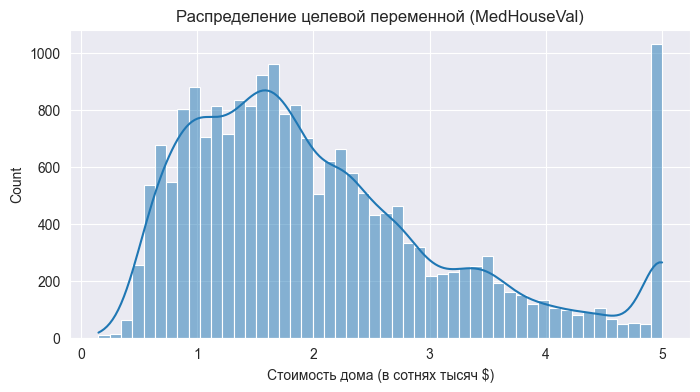

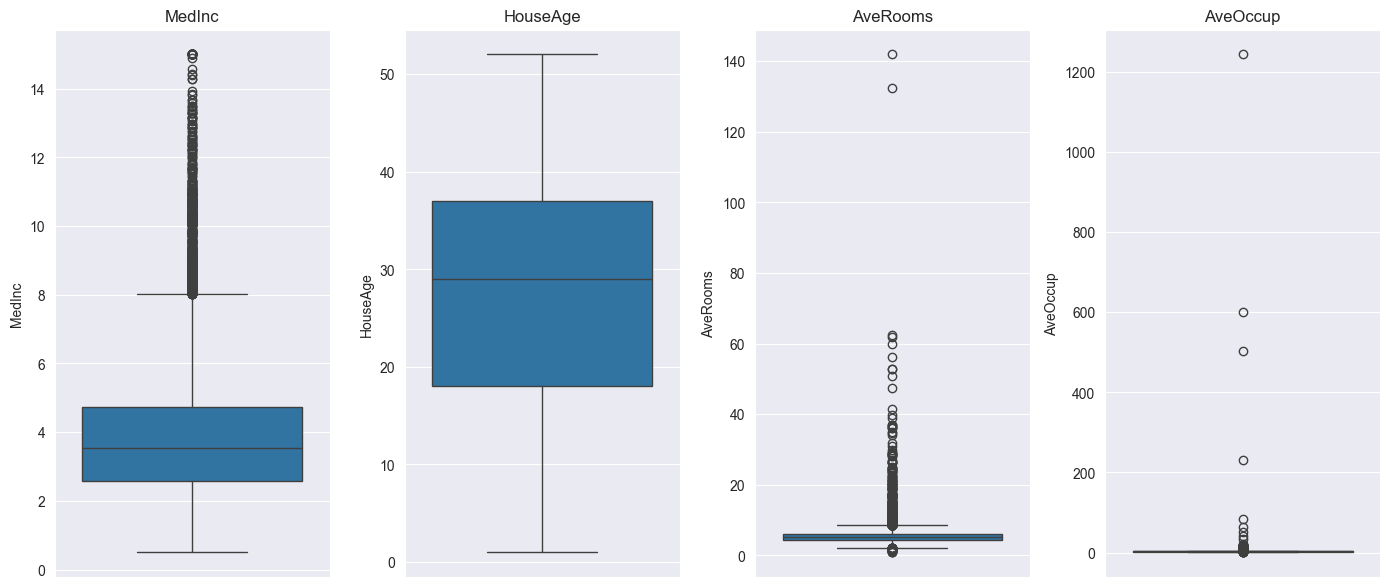

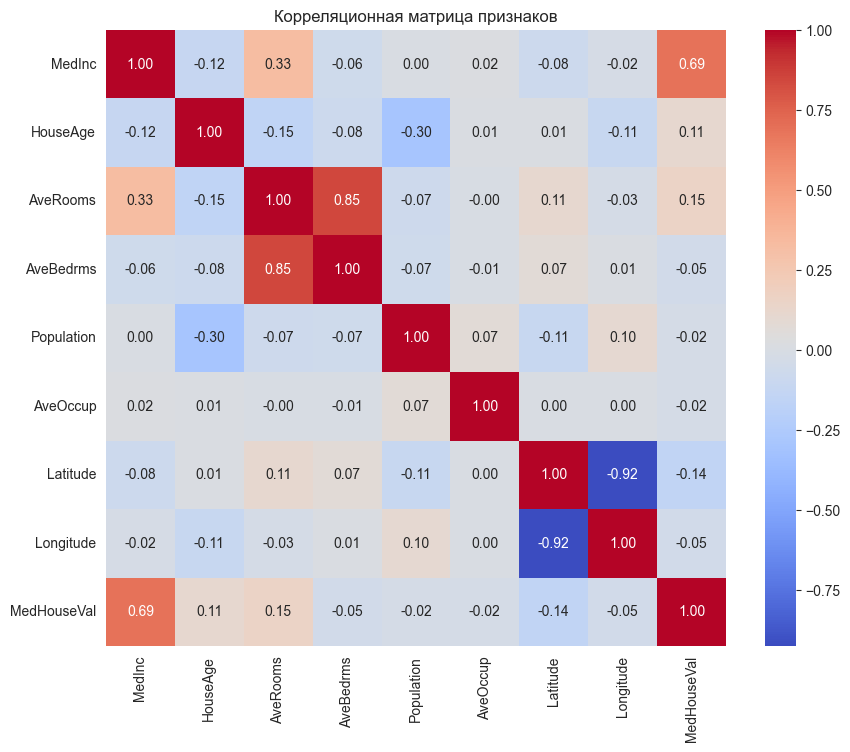

In [10]:
# Таблица результатов
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="RMSE", y="Model", palette="viridis")
plt.title("Сравнение моделей по RMSE")
plt.xlabel("Root Mean Squared Error")
plt.tight_layout()
plt.show()


# Распределение целевой переменной
plt.figure(figsize=(8, 4))
sns.histplot(df["MedHouseVal"], bins=50, kde=True)
plt.title("Распределение целевой переменной (MedHouseVal)")
plt.xlabel("Стоимость дома (в сотнях тысяч $)")
plt.grid(True)
plt.show()

# Ящики с усами (Boxplot) по некоторым признакам
plt.figure(figsize=(14, 6))
for i, col in enumerate(["MedInc", "HouseAge", "AveRooms", "AveOccup"], 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Корреляция
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

In [7]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }
    model = LGBMRegressor(**params)
    return -np.mean(cross_val_score(model, X_train_scaled, y_train, cv=3, scoring="neg_root_mean_squared_error"))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Лучшие параметры LGBM:", study.best_params)
print("Лучшая RMSE (CV):", -study.best_value)

[I 2025-06-15 08:44:55,221] A new study created in memory with name: no-name-019071a2-7145-4a08-908b-f9630a7daa56


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 8
[LightGBM] [Info] Start training from score 2.060785
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2025-06-15 08:44:57,632] Trial 0 finished with value: 0.5068715106640654 and parameters: {'n_estimators': 826, 'learning_rate': 0.15082783677769118, 'num_leaves': 272, 'max_depth': 11, 'min_child_samples': 50}. Best is trial 0 with value: 0.5068715106640654.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000639 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 8
[LightGBM] [Info] Start training from score 2.060785
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2025-06-15 08:44:58,587] Trial 1 finished with value: 0.491621428273173 and parameters: {'n_estimators': 292, 'learning_rate': 0.05592794055139626, 'num_leaves': 189, 'max_depth': 14, 'min_child_samples': 37}. Best is trial 1 with value: 0.491621428273173.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 8
[LightGBM] [Info] Start training from score 2.060785
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2025-06-15 08:45:29,712] Trial 28 finished with value: 0.4881796119570308 and parameters: {'n_estimators': 898, 'learning_rate': 0.04677382452778012, 'num_leaves': 175, 'max_depth': 6, 'min_child_samples': 13}. Best is trial 25 with value: 0.48742806780214143.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 8
[LightGBM] [Info] Start training from score 2.060785
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2025-06-15 08:45:31,210] Trial 29 finished with value: 0.48762938382010274 and parameters: {'n_estimators': 890, 'learning_rate': 0.0331674614436961, 'num_leaves': 170, 'max_depth': 6, 'min_child_samples': 12}. Best is trial 25 with value: 0.48742806780214143.


Лучшие параметры LGBM: {'n_estimators': 856, 'learning_rate': 0.0380147094686801, 'num_leaves': 193, 'max_depth': 6, 'min_child_samples': 6}
Лучшая RMSE (CV): -0.48742806780214143


In [8]:
stacking_estimators = [
    ("rf", RandomForestRegressor()),
    ("lgbm", LGBMRegressor(**study.best_params)),
    ("xgb", XGBRegressor(verbosity=0))
]

stack_model = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=GradientBoostingRegressor(),
    cv=5
)

stack_model.fit(X_train_scaled, y_train)
y_pred_stack = stack_model.predict(X_test_scaled)

stack_rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))
print(f"\nStacking RMSE: {stack_rmse:.4f}")

# --- 6. Сохранение лучшей модели (по RMSE) ---
best_model_name = results_df.iloc[0]["Model"]
final_model = models[best_model_name]
final_model.fit(X_train_scaled, y_train)
joblib.dump(final_model, "best_model.pkl")
print(f"Сохранена модель: {best_model_name} → best_model.pkl")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 8
[LightGBM] [Info] Start training from score 2.057377
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b